# Model B — Maculopathy (M0 / M1) — Performance Metrics

Binary referable-maculopathy screening. This notebook **re-derives** Model B's headline
metrics from the saved cross-validation artifacts and adds the diagnostic plots.

**Recommended configuration:** patient **MEAN** pooling + 4-way TTA (PtMax is near-identical).

Everything below is computed from files under `output_dir/modelB_maculopathy_cv/` plus the
ground-truth `labels/splits.csv` — no model re-run is needed because the per-image
TTA-averaged probabilities are already on disk.

| Metric (expected, from CLAUDE.md) | Value |
|---|---|
| Test AUROC (patient-level, PtMean) | 0.9778 |
| 5-fold OOF AUROC (image-level) | 0.9529 |
| Youden test sens / spec | 0.929 / 0.933 |

The cells recompute these independently and cross-check against `modelB_tta_results.json`.

## 1. Config, ground truth, and fold reconstruction

We rebuild the exact patient→fold assignment used in training
(`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` stratified on patient-worst
maculopathy) so the out-of-fold (OOF) probabilities can be placed back on the right rows.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, confusion_matrix, cohen_kappa_score,
                             matthews_corrcoef, f1_score, brier_score_loss)

sns.set_theme(style='whitegrid', context='talk')

CV        = Path('output_dir/modelB_maculopathy_cv')
FIG_DIR   = Path('figures'); FIG_DIR.mkdir(exist_ok=True)
CLASSES   = ['M0', 'M1']
LABELMAP  = {'M0': 0, 'M1': 1}
N_FOLDS   = 5
SEED      = 42

# ── Ground truth (same construction as modelB_maculopathy.py) ────────────────
df_all = pd.read_csv('labels/splits.csv')
df_all['grade_int'] = df_all['maculopathy'].map(LABELMAP)
df_cv   = df_all[df_all['split'].isin(['train', 'val'])].copy()
df_test = df_all[df_all['split'] == 'test'].copy()

# patient-worst maculopathy -> stratify -> per-patient fold id
pat = df_cv.groupby('code')['grade_int'].max().reset_index()
pat.columns = ['code', 'strat']
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fa = {}
for fi, (_, vidx) in enumerate(skf.split(pat['code'].values, pat['strat'].values)):
    for pid in pat['code'].values[vidx]:
        fa[pid] = fi
pat['fold'] = pat['code'].map(fa)
df_cv = df_cv.reset_index(drop=True); df_cv['cv_idx'] = df_cv.index

print(f'CV pool : {df_cv["code"].nunique():4d} patients / {len(df_cv):5d} images')
print(f'Test    : {df_test["code"].nunique():4d} patients / {len(df_test):5d} images')
print(f'Test M1 image prevalence : {df_test["grade_int"].mean():.3f}')

CV pool : 1824 patients /  7495 images
Test    :  323 patients /  1349 images
Test M1 image prevalence : 0.256


## 2. Load probabilities (image level)

* **Test** — `test_tta_probs.npy`: 4-way TTA, averaged over the 5 folds, row-aligned to
  `df_test['image_path']`.
* **OOF** — each fold's validation probabilities dropped back onto that fold's rows, giving
  one honest (never-trained-on) prediction per CV image.

In [2]:
def _norm(p):
    p = np.asarray(p, dtype=np.float64)
    return p / p.sum(axis=1, keepdims=True)

# Test: image-level TTA probs (row order == df_test order)
test_prob_img = _norm(np.load(CV / 'test_tta_probs.npy'))
test_lbl_img  = df_test['grade_int'].values.astype(int)
assert len(test_prob_img) == len(df_test), 'test prob / df_test row mismatch'

# OOF: reconstruct image-level array from per-fold files
oof_prob_img = np.zeros((len(df_cv), len(CLASSES)), dtype=np.float64)
oof_lbl_img  = np.full(len(df_cv), -1, dtype=int)
for f in range(N_FOLDS):
    vp  = pat[pat['fold'] == f]['code'].values
    idx = df_cv[df_cv['code'].isin(vp)]['cv_idx'].values
    oof_prob_img[idx] = np.load(CV / f'fold_{f}_oof_probs.npy')
    oof_lbl_img[idx]  = np.load(CV / f'fold_{f}_oof_labels.npy')
assert (oof_lbl_img >= 0).all(), 'some CV rows never received an OOF prediction'
oof_prob_img = _norm(oof_prob_img)

print('image-level AUROC  | OOF : %.4f  | TEST : %.4f'
      % (roc_auc_score(oof_lbl_img, oof_prob_img[:, 1]),
         roc_auc_score(test_lbl_img, test_prob_img[:, 1])))

image-level AUROC  | OOF : 0.9529  | TEST : 0.9732


## 3. Patient-level pooling

Each patient has multiple images (eyes / fields). We reduce them to one prediction per
patient, and the patient's label is the **worst** grade across their eyes (M1 if any eye
is M1) — this matches how the clinical outcome is defined.

* **MEAN pooling** (recommended): element-wise average of the image probability vectors.
* **MAX pooling**: element-wise maximum (more sensitive to a single suspicious image).

In [3]:
def pool(df, P, how='mean'):
    """Collapse image probs -> patient probs. Label = worst (max) grade per patient."""
    P = _norm(P)
    rec = {}
    for c, p, g in zip(df['code'].values, P, df['grade_int'].values):
        rec.setdefault(c, {'p': [], 'g': 0})
        rec[c]['p'].append(p)
        rec[c]['g'] = max(rec[c]['g'], int(g))
    ks = sorted(rec)
    A = np.array([(np.mean(rec[k]['p'], 0) if how == 'mean' else np.max(rec[k]['p'], 0))
                  for k in ks])
    A = _norm(A)
    y = np.array([rec[k]['g'] for k in ks])
    return A, y

pooled = {}
for how in ('mean', 'max'):
    oof_A,  oof_y  = pool(df_cv,   oof_prob_img,  how)
    test_A, test_y = pool(df_test, test_prob_img, how)
    pooled[how] = dict(oof_p=oof_A[:, 1], oof_y=oof_y, test_p=test_A[:, 1], test_y=test_y)

for how in ('mean', 'max'):
    d = pooled[how]
    print('Pt%-4s | patients OOF %d / TEST %d | test M1 prevalence %.3f | '
          'AUROC  OOF %.4f  TEST %.4f'
          % (how.upper(), len(d['oof_y']), len(d['test_y']), d['test_y'].mean(),
             roc_auc_score(d['oof_y'], d['oof_p']),
             roc_auc_score(d['test_y'], d['test_p'])))

PtMEAN | patients OOF 1824 / TEST 323 | test M1 prevalence 0.307 | AUROC  OOF 0.9649  TEST 0.9778
PtMAX  | patients OOF 1824 / TEST 323 | test M1 prevalence 0.307 | AUROC  OOF 0.9662  TEST 0.9770


## 4. Operating points (thresholds chosen on OOF, reported on test)

The M1 decision threshold is picked on the OOF predictions (never on test), then applied
to test. Three clinically-motivated rules:

* **Spec ≥ 95%** — high specificity (few false alarms).
* **Sens ≥ 85%** — guaranteed recall floor for a screening tool.
* **Youden** — maximises `sens + spec − 1` (the ROC's top-left corner).

For each we report sensitivity, specificity, PPV, NPV and the confusion counts on test.

In [4]:
def counts(y, s, thr):
    pred = (s >= thr).astype(int)
    tp = int(((pred == 1) & (y == 1)).sum()); fp = int(((pred == 1) & (y == 0)).sum())
    fn = int(((pred == 0) & (y == 1)).sum()); tn = int(((pred == 0) & (y == 0)).sum())
    sens = tp / (tp + fn) if tp + fn else 0.0
    spec = tn / (tn + fp) if tn + fp else 0.0
    ppv  = tp / (tp + fp) if tp + fp else 0.0
    npv  = tn / (tn + fn) if tn + fn else 0.0
    return dict(thr=thr, sens=sens, spec=spec, ppv=ppv, npv=npv,
                tp=tp, fp=fp, fn=fn, tn=tn)

def pick_threshold(y, s, rule):
    """Choose an M1 threshold on OOF scores (y, s) per rule."""
    fpr, tpr, th = roc_curve(y, s)
    if rule == 'Youden':
        return float(th[(tpr - fpr).argmax()])
    grid = np.unique(np.concatenate([th[np.isfinite(th)], np.linspace(0, 1, 1001)]))
    best = None
    for t in grid:
        c = counts(y, s, t)
        if rule == 'spec>=95%' and c['spec'] >= 0.95:
            if best is None or c['sens'] > best[1]: best = (t, c['sens'])
        if rule == 'sens>=85%' and c['sens'] >= 0.85:
            if best is None or c['spec'] > best[1]: best = (t, c['spec'])
    return float(best[0]) if best else 0.5

HOW = 'mean'   # recommended config
d = pooled[HOW]
rows = []
for rule in ('spec>=95%', 'sens>=85%', 'Youden'):
    thr = pick_threshold(d['oof_y'], d['oof_p'], rule)
    c = counts(d['test_y'], d['test_p'], thr)
    rows.append((rule, c))

op_df = pd.DataFrame(
    [{'operating point': r, 'thr': f"{c['thr']:.3f}", 'sens': f"{c['sens']:.3f}",
      'spec': f"{c['spec']:.3f}", 'ppv': f"{c['ppv']:.3f}", 'npv': f"{c['npv']:.3f}",
      'TP': c['tp'], 'FP': c['fp'], 'FN': c['fn'], 'TN': c['tn']} for r, c in rows])
print(f'Patient-level TEST operating points  (Pt{HOW.upper()}, n={len(d["test_y"])}, '
      f'M1={int(d["test_y"].sum())})')
print(f'Patient-level TEST AUROC = {roc_auc_score(d["test_y"], d["test_p"]):.4f}')
op_df

Patient-level TEST operating points  (PtMEAN, n=323, M1=99)
Patient-level TEST AUROC = 0.9778


,operating point,thr,sens,spec,ppv,npv,TP,FP,FN,TN
0,spec>=95%,0.452,0.889,0.960,0.907,0.951,88,9,11,215
1,sens>=85%,0.418,0.899,0.951,0.890,0.955,89,11,10,213
2,Youden,0.367,0.929,0.933,0.860,0.968,92,15,7,209


### Cross-check against `modelB_tta_results.json`

Confirms the notebook reproduces the numbers recorded when the pipeline was run.

In [5]:
ref = json.load(open(CV / 'modelB_tta_results.json'))
print('reference PtMean test AUROC : %.4f   | recomputed : %.4f'
      % (ref['PtMean']['auroc_test'], roc_auc_score(d['test_y'], d['test_p'])))
print('reference PtMax  test AUROC : %.4f   | recomputed : %.4f'
      % (ref['PtMax']['auroc_test'],
         roc_auc_score(pooled['max']['test_y'], pooled['max']['test_p'])))
print()
for rule, c in rows:
    r = ref['PtMean']['operating_points'][rule]
    print('%-9s  recomputed sens/spec %.3f/%.3f   | reference %.3f/%.3f'
          % (rule, c['sens'], c['spec'], r['sens'], r['spec']))

reference PtMean test AUROC : 0.9778   | recomputed : 0.9778
reference PtMax  test AUROC : 0.9770   | recomputed : 0.9770

spec>=95%  recomputed sens/spec 0.889/0.960   | reference 0.889/0.960
sens>=85%  recomputed sens/spec 0.899/0.951   | reference 0.899/0.951
Youden     recomputed sens/spec 0.929/0.933   | reference 0.929/0.933


## 5. Confusion matrix

Patient-level test confusion matrices at two operating points: **Youden** and **Sens ≥ 85%**.
Rows are the true label, columns the prediction.

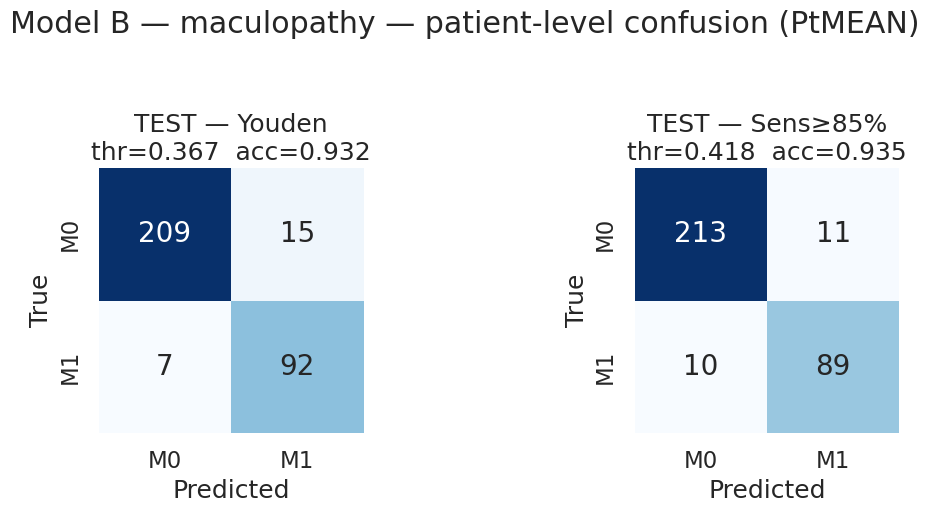

saved figures/modelB_confusion_matrix.png


In [6]:
def plot_cm(ax, y, s, thr, title):
    pred = (s >= thr).astype(int)
    cm = confusion_matrix(y, pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                annot_kws={'size': 20})
    acc = (cm[0, 0] + cm[1, 1]) / cm.sum()
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{title}\nthr={thr:.3f}  acc={acc:.3f}')
    return cm

thr_youden = pick_threshold(d['oof_y'], d['oof_p'], 'Youden')
thr_sens85 = pick_threshold(d['oof_y'], d['oof_p'], 'sens>=85%')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
cm_y = plot_cm(axes[0], d['test_y'], d['test_p'], thr_youden, 'TEST — Youden')
cm_s = plot_cm(axes[1], d['test_y'], d['test_p'], thr_sens85, 'TEST — Sens\u226585%')
fig.suptitle(f'Model B — maculopathy — patient-level confusion (Pt{HOW.upper()})', y=1.04)
fig.tight_layout()
fig.savefig(FIG_DIR / 'modelB_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('saved', FIG_DIR / 'modelB_confusion_matrix.png')

## 6. ROC curve

Patient-level test ROC for both pooling strategies, with the three operating points marked
on the recommended (MEAN) curve.

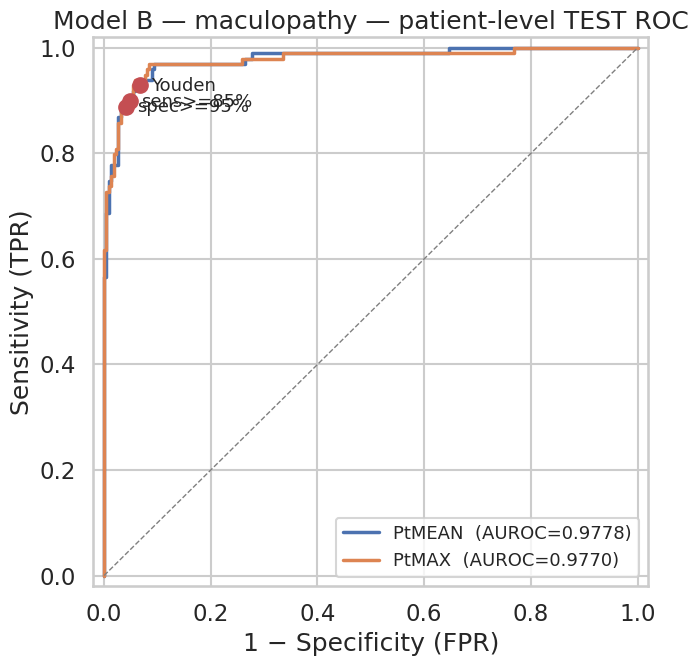

saved figures/modelB_roc_curve.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
for how, colour in (('mean', 'C0'), ('max', 'C1')):
    dd = pooled[how]
    fpr, tpr, _ = roc_curve(dd['test_y'], dd['test_p'])
    auc = roc_auc_score(dd['test_y'], dd['test_p'])
    ax.plot(fpr, tpr, color=colour, lw=2.5,
            label=f'Pt{how.upper()}  (AUROC={auc:.4f})')

for rule, c in rows:
    ax.plot(1 - c['spec'], c['sens'], 'o', ms=11, color='C3', zorder=5)
    ax.annotate(rule, (1 - c['spec'], c['sens']), textcoords='offset points',
                xytext=(8, -4), fontsize=13)

ax.plot([0, 1], [0, 1], '--', color='grey', lw=1)
ax.set_xlabel('1 − Specificity (FPR)'); ax.set_ylabel('Sensitivity (TPR)')
ax.set_title('Model B — maculopathy — patient-level TEST ROC')
ax.legend(loc='lower right', fontsize=13)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'modelB_roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print('saved', FIG_DIR / 'modelB_roc_curve.png')

## 7. Precision–Recall curve

With M1 prevalence ≈ 31%, PR (average precision) complements the ROC by focusing on the
positive class.

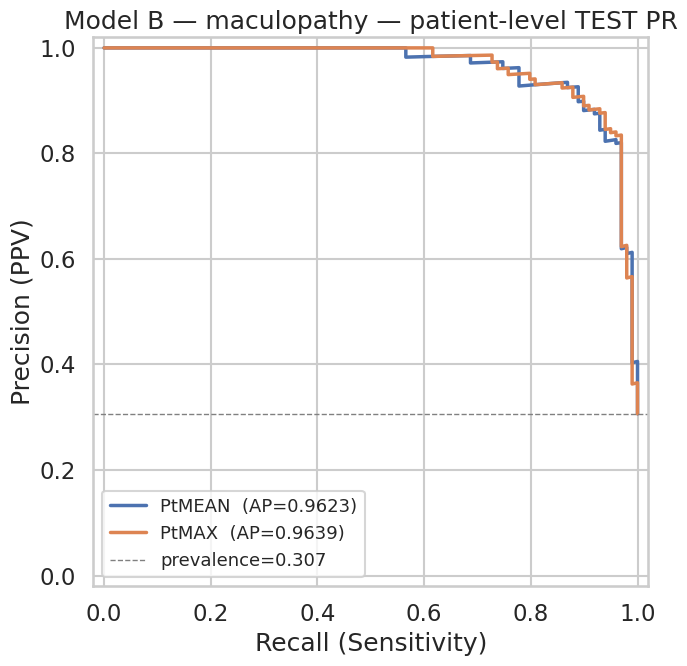

saved figures/modelB_pr_curve.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
for how, colour in (('mean', 'C0'), ('max', 'C1')):
    dd = pooled[how]
    prec, rec, _ = precision_recall_curve(dd['test_y'], dd['test_p'])
    ap = average_precision_score(dd['test_y'], dd['test_p'])
    ax.plot(rec, prec, color=colour, lw=2.5,
            label=f'Pt{how.upper()}  (AP={ap:.4f})')

base = d['test_y'].mean()
ax.axhline(base, ls='--', color='grey', lw=1, label=f'prevalence={base:.3f}')
ax.set_xlabel('Recall (Sensitivity)'); ax.set_ylabel('Precision (PPV)')
ax.set_title('Model B — maculopathy — patient-level TEST PR')
ax.legend(loc='lower left', fontsize=13)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'modelB_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print('saved', FIG_DIR / 'modelB_pr_curve.png')

## 8. Score distribution & calibration

* **Left** — histogram of predicted M1 probability split by true class; good separation
  means the two colours sit at opposite ends.
* **Right** — reliability curve: predicted probability vs observed M1 frequency in 10 bins.
  Closer to the diagonal = better calibrated. Brier score summarises calibration+sharpness
  (lower is better).

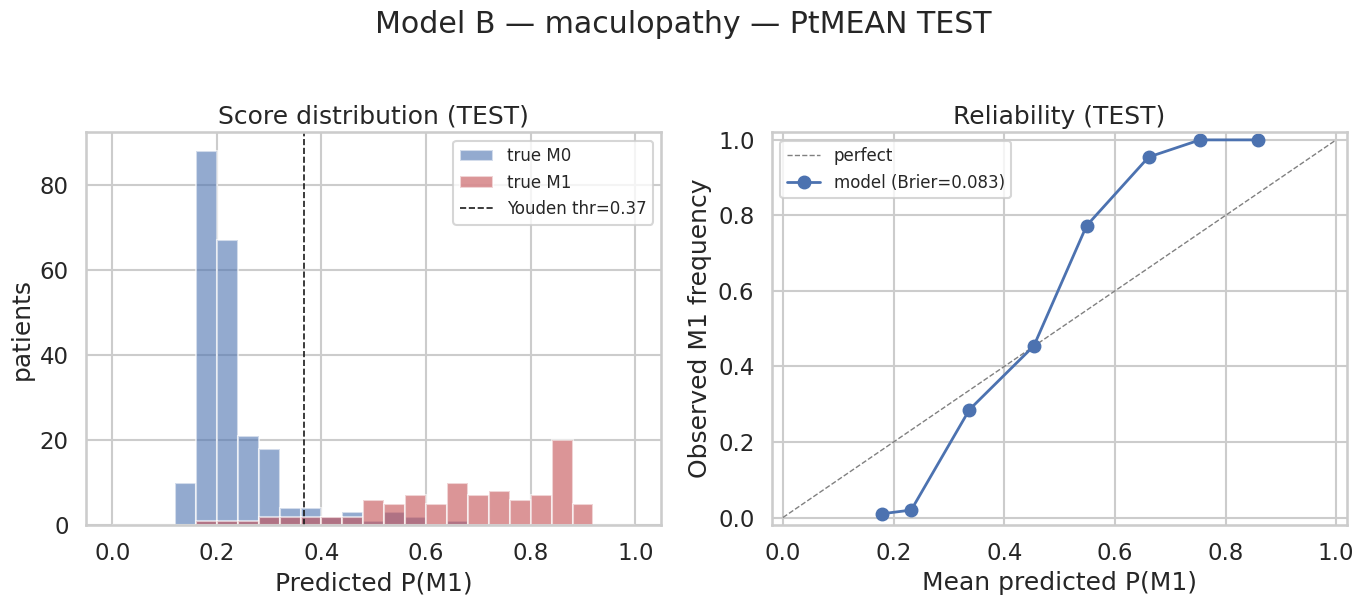

saved figures/modelB_score_calibration.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# score histogram
s = d['test_p']; y = d['test_y']
bins = np.linspace(0, 1, 26)
axes[0].hist(s[y == 0], bins=bins, alpha=0.6, color='C0', label='true M0')
axes[0].hist(s[y == 1], bins=bins, alpha=0.6, color='C3', label='true M1')
axes[0].axvline(thr_youden, ls='--', color='k', lw=1.2, label=f'Youden thr={thr_youden:.2f}')
axes[0].set_xlabel('Predicted P(M1)'); axes[0].set_ylabel('patients')
axes[0].set_title('Score distribution (TEST)'); axes[0].legend(fontsize=12)

# reliability curve
nb = 10
edges = np.linspace(0, 1, nb + 1)
idx = np.clip(np.digitize(s, edges) - 1, 0, nb - 1)
xs, ys = [], []
for b in range(nb):
    m = idx == b
    if m.sum():
        xs.append(s[m].mean()); ys.append(y[m].mean())
brier = brier_score_loss(y, s)
axes[1].plot([0, 1], [0, 1], '--', color='grey', lw=1, label='perfect')
axes[1].plot(xs, ys, 'o-', color='C0', lw=2, ms=9, label=f'model (Brier={brier:.3f})')
axes[1].set_xlabel('Mean predicted P(M1)'); axes[1].set_ylabel('Observed M1 frequency')
axes[1].set_title('Reliability (TEST)'); axes[1].legend(fontsize=12)
axes[1].set_xlim(-0.02, 1.02); axes[1].set_ylim(-0.02, 1.02)

fig.suptitle(f'Model B — maculopathy — Pt{HOW.upper()} TEST', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'modelB_score_calibration.png', dpi=120, bbox_inches='tight')
plt.show()
print('saved', FIG_DIR / 'modelB_score_calibration.png')

## 9. Summary table + JSON

Threshold-free (AUROC / AP) plus threshold-dependent (at the Youden operating point:
accuracy, F1, MCC, quadratic κ) metrics for the recommended PtMEAN config, written to
`output_dir/modelB_maculopathy_cv/modelB_metrics_notebook_summary.json`.

In [10]:
pred_y = (d['test_p'] >= thr_youden).astype(int)
c = counts(d['test_y'], d['test_p'], thr_youden)
summary = {
    'config': f'Pt{HOW.upper()} + 4-way TTA',
    'n_test_patients': int(len(d['test_y'])),
    'n_test_M1': int(d['test_y'].sum()),
    'auroc_test': float(roc_auc_score(d['test_y'], d['test_p'])),
    'auroc_oof': float(roc_auc_score(d['oof_y'], d['oof_p'])),
    'auroc_oof_image_level': float(roc_auc_score(oof_lbl_img, oof_prob_img[:, 1])),
    'average_precision_test': float(average_precision_score(d['test_y'], d['test_p'])),
    'brier_test': float(brier_score_loss(d['test_y'], d['test_p'])),
    'youden': {
        'thr': float(thr_youden),
        'sensitivity': c['sens'], 'specificity': c['spec'],
        'ppv': c['ppv'], 'npv': c['npv'],
        'accuracy': float((pred_y == d['test_y']).mean()),
        'f1': float(f1_score(d['test_y'], pred_y)),
        'mcc': float(matthews_corrcoef(d['test_y'], pred_y)),
        'quadratic_kappa': float(cohen_kappa_score(d['test_y'], pred_y, weights='quadratic')),
        'confusion': {'tp': c['tp'], 'fp': c['fp'], 'fn': c['fn'], 'tn': c['tn']},
    },
    'operating_points': {r: cc for r, cc in rows},
}
with open(CV / 'modelB_metrics_notebook_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"{'metric':<26}{'value':>10}")
print('-' * 36)
for k in ('auroc_test', 'auroc_oof_image_level', 'average_precision_test', 'brier_test'):
    print(f'{k:<26}{summary[k]:>10.4f}')
for k in ('sensitivity', 'specificity', 'ppv', 'npv', 'accuracy', 'f1', 'mcc',
          'quadratic_kappa'):
    print(f'{("youden."+k):<26}{summary["youden"][k]:>10.4f}')
print('\nsaved', CV / 'modelB_metrics_notebook_summary.json')

metric                         value
------------------------------------
auroc_test                    0.9778
auroc_oof_image_level         0.9529
average_precision_test        0.9623
brier_test                    0.0832
youden.sensitivity            0.9293
youden.specificity            0.9330
youden.ppv                    0.8598
youden.npv                    0.9676
youden.accuracy               0.9319
youden.f1                     0.8932
youden.mcc                    0.8447
youden.quadratic_kappa        0.8433

saved output_dir/modelB_maculopathy_cv/modelB_metrics_notebook_summary.json


## Takeaway

Binary maculopathy is a much cleaner problem than 4-class DR grading: patient-level test
AUROC ≈ **0.978** with sensitivity ≈ 0.89–0.93 and specificity ≈ 0.93–0.96 held
**simultaneously** — no minority-class collapse. Focal loss alone (no class weights, no
sampler) was stable because the classes are near-balanced (M1 ≈ 31% on test). Figures are
saved under `figures/modelB_*.png`.